In [ ]:
#特征值缩放 
#模型学习由原本区别较大的几个变量的影响，导致的学习率只能设置的特别低，不然梯度下降会被基数值最大的那个书主导梯度的下降
#特征缩放，将所有变量缩放到接近的水平值以及对模型训练的影响减小，大大增加率模型的训练效率
import numpy as np
import copy
X_train=np.array([[1244,3,1,64],[1947,3,2,17],[1725,3,2,42],[1959,3,2,15],[1314,2,1,14],[864,2,1,66],[1836,3,1,17],[1026,3,1,43],[3194,4,2,87],[788,2,1,80],[1200,2,2,17],[1557,2,1,18],[1430,3,1,20],[1220,2,1,15],[1092,2,1,64],[848,1,1,17],[1682,3,2,23],[1768,3,2,18],[1040,3,1,44],[1652,2,1,21],[1088,2,1,35],[1316,3,1,14],[1593,0,1,20],[972,2,1,73],[1097,3,1,37],[1004,2,1,51],[904,3,1,55],[1694,3,1,13],[1073,2,1,100],[1419,3,2,19],[1164,3,1,52],[1935,3,2,12],[1216,2,2,74],[2482,4,2,16],[1200,2,1,18],[1840,3,2,20],[1851,3,2,57],[1660,3,2,19],[1096,2,2,97],[1775,3,2,28],[2030,4,2,45],[1784,4,2,107],[1073,2,1,100],[1552,3,1,16],[1953,3,2,16],[1224,2,2,12],[1616,3,1,16],[816,2,1,58],[1349,3,1,21],[1571,3,1,14],[1486,3,1,57],[1506,2,1,16],[1097,3,1,27],[1764,3,2,24],[1208,2,1,14],[1470,3,2,24],[1768,3,2,84],[1654,3,1,19],[1029,3,1,60],[1120,2,2,16],[1150,3,1,62],[816,2,1,39],[1040,3,1,25],[1392,3,1,64],[1603,3,2,29],[1215,3,1,63],[1073,2,1,100],[2599,4,2,22],[1431,3,1,59],[2090,3,2,26],[1790,4,2,49],[1484,3,2,16],[1040,3,1,25],[1431,3,1,22],[1159,3,1,53],[1547,3,2,12],[1983,3,2,22],[1056,3,1,53],[1180,2,1,99],[1358,2,1,17],[960,3,1,51],[1456,3,2,16],[1446,3,2,25],[1208,2,1,15],[1553,3,2,16],[882,3,1,49],[2030,4,2,45],[1040,3,1,62],[1616,3,1,16],[803,2,1,80],[1430,3,2,21],[1656,3,1,61],[1541,3,1,16],[948,3,1,53],[1224,2,2,12],[1432,2,1,43],[1660,3,2,19],[1212,3,1,20],[1050,2,1,65]])
y_train = np.array([
    300, 509.8, 394, 540, 415, 230, 560, 294, 718.2, 200,
    302, 468, 374.2, 388, 282, 311.8, 401, 449.8, 301, 502,
    340, 400.3, 572, 264, 304, 298, 219.8, 490.7, 217, 368.2,
    280, 526.9, 237, 562.4, 369.8, 460, 374, 390, 158, 426,
    390, 277.8, 217, 425.8, 504, 329, 464, 220, 358, 478,
    334, 427, 290, 463, 390.8, 354, 350, 460, 237, 288.3,
    282, 249, 304, 332, 351.8, 310, 217, 666.3, 330, 480,
    330.3, 348, 304, 384, 316, 430.4, 450, 284, 275, 414,
    258, 378, 350, 412, 373, 225, 390, 267.4, 464, 174, 340,
    430, 440, 216, 329, 388, 390, 356, 257.8
])
def cost_function(x,y,w,b):
    m=x.shape[0]
    j_wb=0
    for i in range(m):
        f_wb=np.dot(x[i],w)+b
        j_wb_i=(f_wb-y[i])**2
        j_wb+=j_wb_i
    j_wb=j_wb/(2*m)
    return j_wb

#计算偏导，返回一个数组，一个整数
def partial(x,y,w,b):
    m,n=x.shape          #其中m,n分别为x的行列数
    dj_dw=np.zeros(n)
    dj_db=0
    for i in range(m):
        err=np.dot(x[i],w)+b-y[i]
        for j in range(n):
            dj_dw[j]+=err*(x[i,j])
        dj_db+=err
    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_dw,dj_db

def feature_scaling(x):
    x_mean=np.mean(x,axis=0)
    sigema=np.std(x,axis=0)
    x_nom=(x-x_mean)/sigema
    return x_nom,x_mean,sigema

def gradient_descent(x,y,w_in,b_in,alpha,num_iters,cost_function,partial):
    j_history=[]
    b=b_in
    w=copy.deepcopy(w_in)
    
    for i in range(num_iters):
        dj_dw, dj_db = partial(x,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        j_history.append(cost_function(x,y,w,b))
        if i%10==0:
           print(f"Iteration {i:4d}  Cost: {j_history[-1]:.6f} w0:{w[0]:0.3e} w1:{w[1]:0.3e} w2:{w[2]:0.3e} w3:{w[3]:0.3e} b:{b:0.3e} dj_w0:{dj_dw[0]:0.3e} dj_w1:{dj_dw[1]:0.3e} dj_w2:{dj_dw[2]:0.3e} dj_w3:{dj_dw[3]:0.3e} dj_db:{dj_db:0.3e}")
    return w, b, j_history

x_nom,x_mean,sigema=feature_bian hauscaling(X_train)
w_init=np.zeros(X_train.shape[1])
b_init=0
alpha=1.0e-1
num_iters=100
w_fina,b_fina,j_history=gradient_descent(x_nom,y_train,w_init,b_init,alpha,num_iters,cost_function,partial)
print(f"经过梯度下降得到的结果：w:{w_fina} b:{b_fina:.2f}")


Iteration    0  Cost: 57617.272258 w0:8.914e+00 w1:2.952e+00 w2:3.282e+00 w3:-5.961e+00 b:3.632e+01 dj_w0:-8.914e+01 dj_w1:-2.952e+01 dj_w2:-3.282e+01 dj_w3:5.961e+01 dj_db:-3.632e+02
Iteration   10  Cost: 7694.654045 w0:5.236e+01 w1:4.799e+00 w2:3.705e+00 w3:-3.369e+01 b:2.492e+02 dj_w0:-2.493e+01 dj_w1:6.870e+00 dj_w2:1.004e+01 dj_w3:1.300e+01 dj_db:-1.266e+02
Iteration   20  Cost: 1462.582159 w0:7.034e+01 w1:-2.417e+00 w2:-6.772e+00 w3:-4.009e+01 b:3.234e+02 dj_w0:-1.426e+01 dj_w1:6.583e+00 dj_w2:9.630e+00 dj_w3:2.976e+00 dj_db:-4.415e+01
Iteration   30  Cost: 539.260998 w0:8.200e+01 w1:-7.868e+00 w2:-1.478e+01 w3:-4.127e+01 b:3.493e+02 dj_w0:-9.878e+00 dj_w1:4.602e+00 dj_w2:6.744e+00 dj_w3:2.162e-01 dj_db:-1.539e+01
Iteration   40  Cost: 343.300913 w0:9.022e+01 w1:-1.167e+01 w2:-2.028e+01 w3:-4.100e+01 b:3.583e+02 dj_w0:-7.024e+00 dj_w1:3.231e+00 dj_w2:4.607e+00 dj_w3:-5.224e-01 dj_db:-5.368e+00
Iteration   50  Cost: 277.323711 w0:9.608e+01 w1:-1.436e+01 w2:-2.404e+01 w3:-4.039e+01

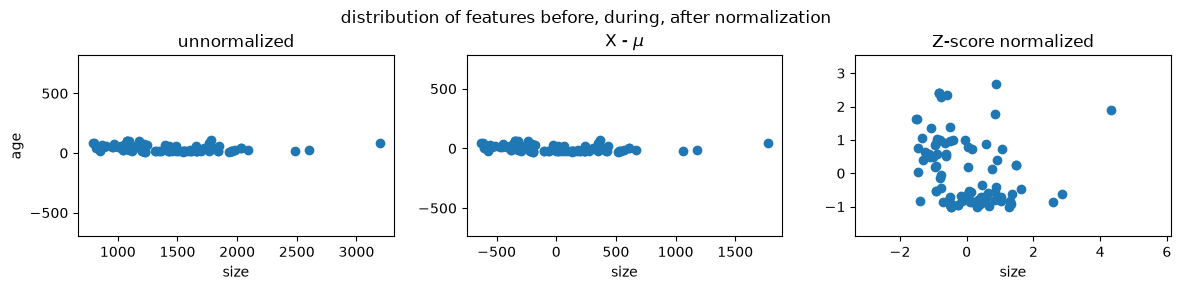

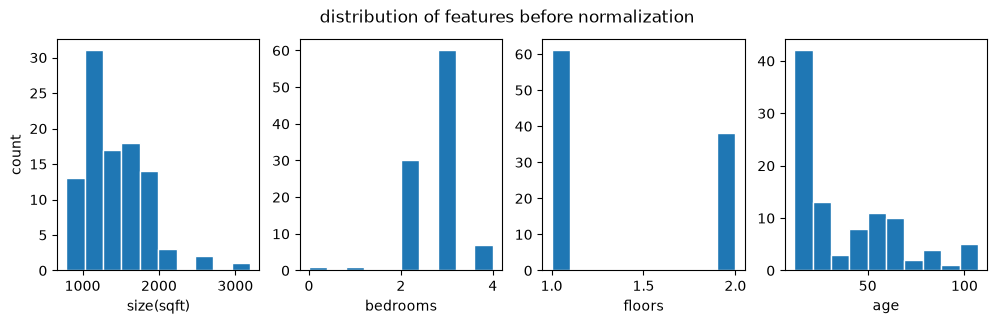

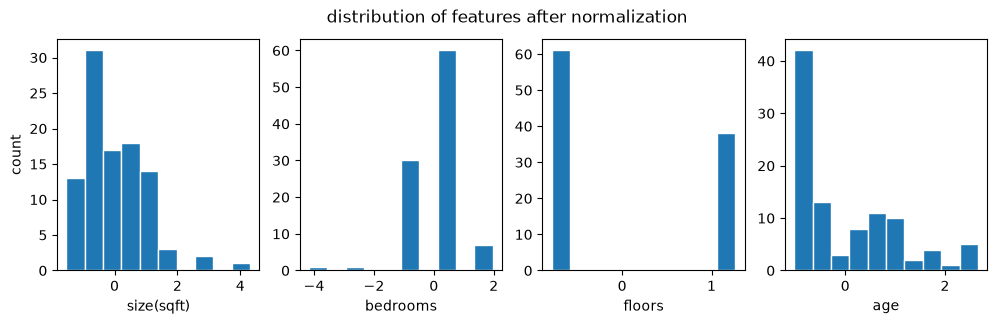

In [14]:
import matplotlib.pyplot as plt
X_train=np.array([[1244,3,1,64],[1947,3,2,17],[1725,3,2,42],[1959,3,2,15],[1314,2,1,14],[864,2,1,66],[1836,3,1,17],[1026,3,1,43],[3194,4,2,87],[788,2,1,80],[1200,2,2,17],[1557,2,1,18],[1430,3,1,20],[1220,2,1,15],[1092,2,1,64],[848,1,1,17],[1682,3,2,23],[1768,3,2,18],[1040,3,1,44],[1652,2,1,21],[1088,2,1,35],[1316,3,1,14],[1593,0,1,20],[972,2,1,73],[1097,3,1,37],[1004,2,1,51],[904,3,1,55],[1694,3,1,13],[1073,2,1,100],[1419,3,2,19],[1164,3,1,52],[1935,3,2,12],[1216,2,2,74],[2482,4,2,16],[1200,2,1,18],[1840,3,2,20],[1851,3,2,57],[1660,3,2,19],[1096,2,2,97],[1775,3,2,28],[2030,4,2,45],[1784,4,2,107],[1073,2,1,100],[1552,3,1,16],[1953,3,2,16],[1224,2,2,12],[1616,3,1,16],[816,2,1,58],[1349,3,1,21],[1571,3,1,14],[1486,3,1,57],[1506,2,1,16],[1097,3,1,27],[1764,3,2,24],[1208,2,1,14],[1470,3,2,24],[1768,3,2,84],[1654,3,1,19],[1029,3,1,60],[1120,2,2,16],[1150,3,1,62],[816,2,1,39],[1040,3,1,25],[1392,3,1,64],[1603,3,2,29],[1215,3,1,63],[1073,2,1,100],[2599,4,2,22],[1431,3,1,59],[2090,3,2,26],[1790,4,2,49],[1484,3,2,16],[1040,3,1,25],[1431,3,1,22],[1159,3,1,53],[1547,3,2,12],[1983,3,2,22],[1056,3,1,53],[1180,2,1,99],[1358,2,1,17],[960,3,1,51],[1456,3,2,16],[1446,3,2,25],[1208,2,1,15],[1553,3,2,16],[882,3,1,49],[2030,4,2,45],[1040,3,1,62],[1616,3,1,16],[803,2,1,80],[1430,3,2,21],[1656,3,1,61],[1541,3,1,16],[948,3,1,53],[1224,2,2,12],[1432,2,1,43],[1660,3,2,19],[1212,3,1,20],[1050,2,1,65]])
mu= np.mean(X_train,axis=0)   
sigma  = np.std(X_train,axis=0) 
X_mean = (X_train - mu)
X_norm = (X_train - mu)/sigma      

fig,ax=plt.subplots(1, 3, figsize=(12, 3))
ax[0].scatter(X_train[:,0], X_train[:,3])
ax[0].set_xlabel("size"); ax[0].set_ylabel("age")
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(X_mean[:,0], X_mean[:,3])
ax[1].set_xlabel("size"); ax[0].set_ylabel("age")
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(X_norm[:,0], X_norm[:,3])
ax[2].set_xlabel("size"); ax[0].set_ylabel("age")
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()

X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']
fig,ax=plt.subplots(1, 4, figsize=(12, 3))
for i in range(len(ax)):
    ax[i].hist(X_train[:, i], bins=10, edgecolor='white')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count");
fig.suptitle("distribution of features before normalization")
plt.show()
fig,ax=plt.subplots(1,4,figsize=(12,3))
for i in range(len(ax)):
    ax[i].hist(X_norm[:, i], bins=10, edgecolor='white')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("count"); 
fig.suptitle(f"distribution of features after normalization")
plt.show()